# Forecasting and Visualizing AWS Cloud Costs

## Summary

A data analysis and forecasting project exploring AWS usage and cost patterns — combining exploratory data analysis, visualization, and simple predictive modeling to understand what drives cloud spend over time.


In [1]:
# ===============================================================
# Step 0: Importing Required Python Libraries
# ---------------------------------------------------------------
# Objective:
# Import all essential libraries required for data analysis,
# visualization, and machine learning.
#
# This step ensures all modules are available before we proceed.
# ===============================================================

# ---------------------------------------------------------------
# Pandas – For data manipulation and analysis
# ---------------------------------------------------------------
# Used to load, clean, and explore tabular data (CSV, Excel, SQL, etc.)
# Documentation: https://pandas.pydata.org/
# Tutorial: https://www.w3schools.com/python/pandas/default.asp
import pandas as pd  # Common alias used in the Python data community

# ---------------------------------------------------------------
# NumPy – For efficient numerical operations
# ---------------------------------------------------------------
# Supports mathematical operations, arrays, and matrix computations
# Documentation: https://numpy.org/doc/
# Tutorial: https://www.w3schools.com/python/numpy/default.asp
import numpy as np  # Essential for high-performance math functions

# ---------------------------------------------------------------
# Matplotlib – For basic data visualization
# ---------------------------------------------------------------
# Useful for creating line plots, bar charts, pie charts, etc.
# Documentation: https://matplotlib.org/stable/contents.html
# Tutorial: https://www.w3schools.com/python/matplotlib_intro.asp
import matplotlib.pyplot as plt  # plt is the standard plotting alias

# ---------------------------------------------------------------
# Seaborn – For statistical and advanced plots
# ---------------------------------------------------------------
# Built on top of matplotlib, provides high-level plotting API
# Best for box plots, violin plots, heatmaps, etc.
# Documentation: https://seaborn.pydata.org/
import seaborn as sns  # sns is the commonly used alias for seaborn

# ---------------------------------------------------------------
# Scikit-learn – For machine learning algorithms
# ---------------------------------------------------------------
# This block loads specific ML tools for data scaling, clustering, and regression
# Full Documentation: https://scikit-learn.org/stable/

# StandardScaler: Used to normalize feature values (mean=0, std=1)
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler

# KMeans: Clustering algorithm to categorize similar data points
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
from sklearn.cluster import KMeans

# LinearRegression: Predicts continuous numerical values
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------------
# Seaborn Style Configuration – Improve plot appearance
# ---------------------------------------------------------------
# Sets default aesthetic style for all seaborn plots to 'whitegrid'
# Reference: https://seaborn.pydata.org/generated/seaborn.set.html
sns.set(style="whitegrid")

# ---------------------------------------------------------------
# OS – Operating System functions (like file existence checks)
# ---------------------------------------------------------------
# Used for path operations, like checking if a file exists before loading
# Documentation: https://docs.python.org/3/library/os.html
import os  # Included here to support os.path.exists() and directory checks


In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = '#1a0e0a'
plt.rcParams['axes.facecolor'] = '#1a0e0a'
plt.rcParams['savefig.facecolor'] = '#1a0e0a'
plt.rcParams['text.color'] = '#fff7ed'
plt.rcParams['axes.labelcolor'] = '#fff7ed'
plt.rcParams['xtick.color'] = '#fff7ed'
plt.rcParams['ytick.color'] = '#fff7ed'
plt.rcParams['axes.edgecolor'] = '#5a3a28'
plt.rcParams['grid.color'] = '#5a3a28'
plt.rcParams['axes.titlecolor'] = '#fff7ed'
plt.rcParams['legend.facecolor'] = '#1a0e0a'
plt.rcParams['legend.edgecolor'] = '#5a3a28'
plt.rcParams['legend.labelcolor'] = '#fff7ed'
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=['#ffb703','#ff6b1a','#e8290a','#ff8c42','#c9440c'])


## Step 1: Load the Dataset


In [3]:
# Load the AWS usage dataset (bundled alongside this notebook)
csv_filename = 'aws_usage.csv'
df = pd.read_csv(csv_filename)

# Convert the Date column to datetime for time-series operations
df['Date'] = pd.to_datetime(df['Date'])

df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1000 non-null   datetime64[us]
 1   Service     1000 non-null   str           
 2   Region      1000 non-null   str           
 3   UsageHours  1000 non-null   float64       
 4   Cost        1000 non-null   float64       
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 39.2 KB


,Date,Service,Region,UsageHours,Cost
0,2023-02-21,AWS Lambda,us-east-1,8.96,20.64
1,2023-01-15,Amazon EC2,eu-west-1,8.25,46.76
2,2023-03-13,Amazon CloudFront,eu-west-1,18.75,21.58
3,2023-03-02,Amazon RDS,eu-west-1,2.99,43.91
4,2023-01-21,AWS Lambda,ap-south-1,6.45,30.31


In [4]:
# ===============================================================
# Step 6: Grouped Summaries – Service, Region, and Date
# ---------------------------------------------------------------
# Objective:
# Use `groupby()` and aggregation to compute summary statistics
# such as total cost and usage hours by:
#   1. AWS Service
#   2. AWS Region
#   3. Date (daily trend)
# ---------------------------------------------------------------
# These summaries help identify:
# - Most expensive services
# - High-usage regions
# - Daily billing patterns for time series analysis
# ===============================================================

# ---------------------------------------------------------------
# 1. Group by AWS Service
# ---------------------------------------------------------------
# Group data by 'Service' column and aggregate both 'Cost' and 'UsageHours'
# Reference: https://www.w3schools.com/python/pandas/pandas_groupby.asp
service_summary = df.groupby('Service').agg({
    'Cost': 'sum',           # Sum of costs per service
    'UsageHours': 'sum'      # Sum of usage hours per service
}).sort_values(by='Cost', ascending=False)  # Sort services by cost (high to low)

# Display the result
print("Service-wise Cost & Usage Summary:")
print(service_summary)

# ---------------------------------------------------------------
# 2. Group by AWS Region
# ---------------------------------------------------------------
# Aggregate cost and usage per geographical region
# Helps identify which AWS zones are most active or expensive
region_summary = df.groupby('Region').agg({
    'Cost': 'sum',           # Total cost in each region
    'UsageHours': 'sum'      # Total usage in hours
}).sort_values(by='Cost', ascending=False)

# Display the result
print("\nRegion-wise Cost & Usage Summary:")
print(region_summary)

# ---------------------------------------------------------------
# 3. Group by Date
# ---------------------------------------------------------------
# Summarize data day-by-day to prepare for time series analysis
# We use `.reset_index()` to convert the grouped 'Date' back into a column
# Reference: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html
daily_summary = df.groupby('Date').agg({
    'Cost': 'sum',           # Total cost per day
    'UsageHours': 'sum'      # Total usage hours per day
}).reset_index()  # Keeps 'Date' as a column rather than index

# Preview the first few rows to verify
print("\nDaily Cost & Usage Summary (first 5 rows):")
print(daily_summary.head())


Service-wise Cost & Usage Summary:
                      Cost  UsageHours
Service                               
Amazon S3          5612.18     2557.10
Amazon CloudFront  5153.89     2801.06
Amazon EC2         5119.19     2593.71
AWS Lambda         5021.07     2395.66
Amazon RDS         4480.26     2286.48

Region-wise Cost & Usage Summary:
               Cost  UsageHours
Region                         
us-west-2   6800.15     3153.22
ap-south-1  6470.31     3418.34
us-east-1   6146.10     3170.28
eu-west-1   5970.03     2892.17

Daily Cost & Usage Summary (first 5 rows):
        Date    Cost  UsageHours
0 2023-01-01  487.24      253.53
1 2023-01-02  437.52      199.66
2 2023-01-03  287.10      170.75
3 2023-01-04  289.10      174.35
4 2023-01-05  302.96      163.03


/tmp/ipykernel_641/3284925204.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Cost', y='Service', estimator=sum, ci=None)  # Create bar chart with summed cost per service


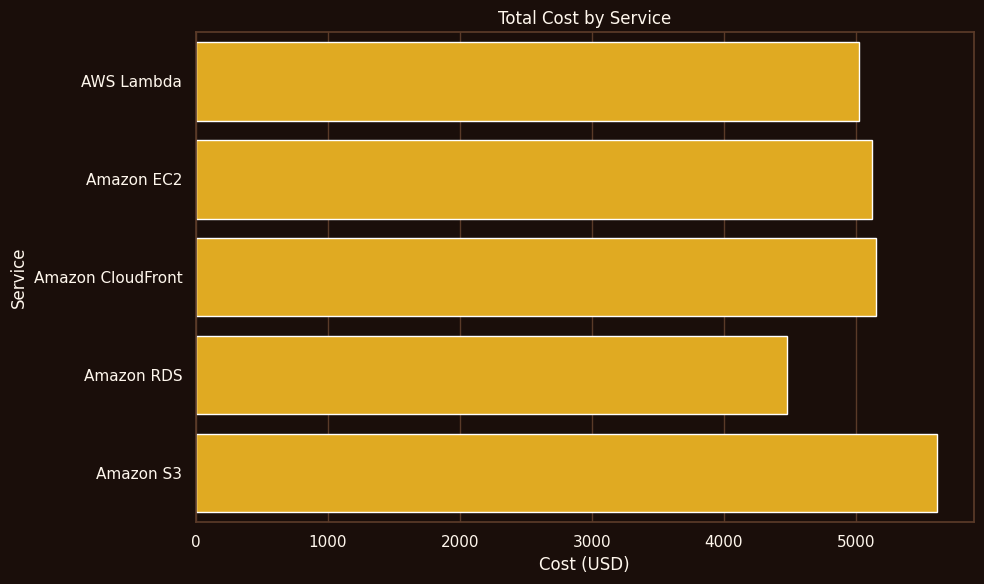

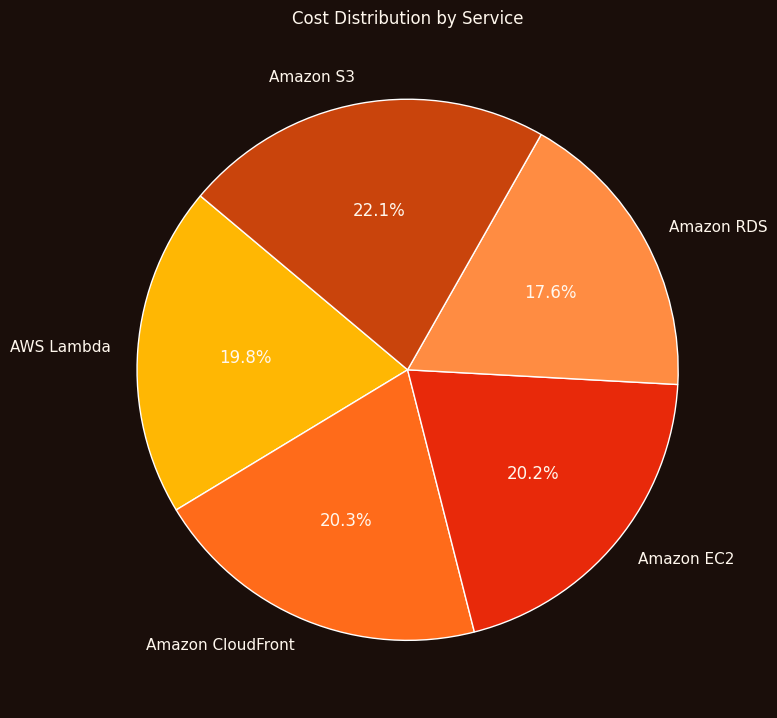

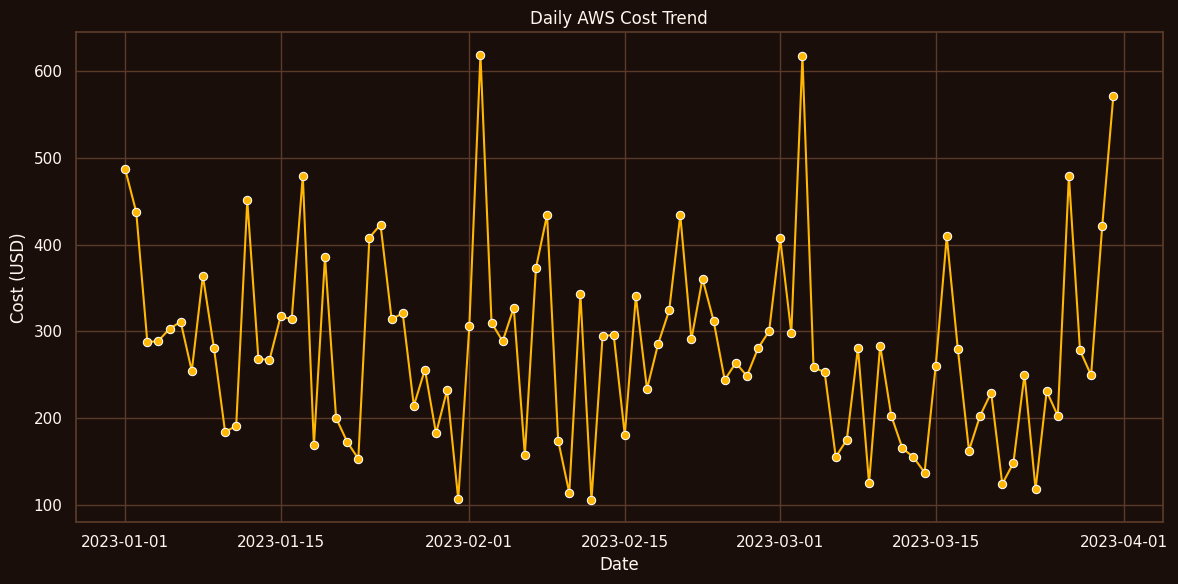

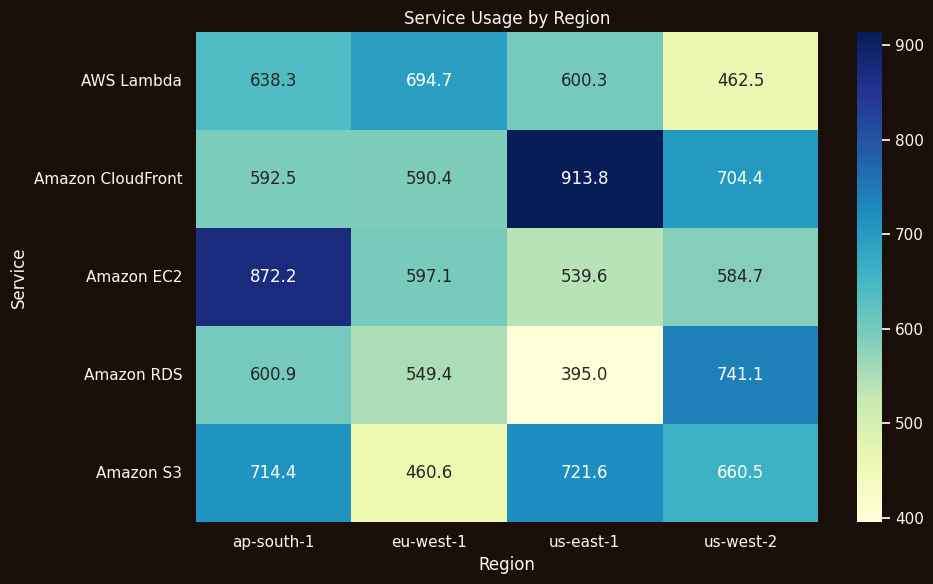

In [5]:
# ===============================================================
# Step 7: Visualizations – Cost & Usage Insights
# ---------------------------------------------------------------
# Objective:
# Use charts to visually understand AWS cost distribution and usage patterns.
# We'll explore:
# 1. Which services are driving costs
# 2. How costs are trending over time
# 3. Regional usage distribution
# ===============================================================

# ---------------------------------------------------------------
# 1. Bar Chart – Total Cost by AWS Service
# ---------------------------------------------------------------
# Purpose: Show top cost-contributing services.
# Seaborn's `barplot()` uses 'Cost' on X and 'Service' on Y, aggregated using `sum`.
# Reference: https://seaborn.pydata.org/generated/seaborn.barplot.html
plt.figure(figsize=(10, 6))  # Set the figure size
sns.barplot(data=df, x='Cost', y='Service', estimator=sum, ci=None)  # Create bar chart with summed cost per service
plt.title("Total Cost by Service")  # Title of chart
plt.xlabel("Cost (USD)")            # X-axis label
plt.ylabel("Service")               # Y-axis label
plt.tight_layout()                  # Prevent clipping of labels
plt.show()                          # Render the chart

# ---------------------------------------------------------------
# 2. Pie Chart – Cost Proportion by Service
# ---------------------------------------------------------------
# Purpose: Show percentage contribution of each service to total cost.
# We'll group cost by service and visualize with matplotlib's `pie()`.
# Reference: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html
service_costs = df.groupby('Service')['Cost'].sum()  # Aggregate total cost per service

plt.figure(figsize=(8, 8))  # Make the pie chart square
plt.pie(
    service_costs,                    # Values
    labels=service_costs.index,       # Labels (Service names)
    autopct='%1.1f%%',                # Show percentage on chart
    startangle=140                    # Rotate for better layout
)
plt.title("Cost Distribution by Service")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 3. Line Chart – Daily Cost Trend Over Time
# ---------------------------------------------------------------
# Purpose: Show how costs vary by date for time-series analysis or forecasting.
# We'll sum daily costs and plot using Seaborn's `lineplot()`.
# Reference: https://seaborn.pydata.org/generated/seaborn.lineplot.html
daily = df.groupby('Date')['Cost'].sum().reset_index()  # Aggregate cost by date

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily, x='Date', y='Cost', marker='o')  # Line chart with points
plt.title("Daily AWS Cost Trend")  # Add title
plt.xlabel("Date")                # X-axis label
plt.ylabel("Cost (USD)")          # Y-axis label
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 4. Heatmap – Service Usage Hours by Region
# ---------------------------------------------------------------
# Purpose: Show which regions have high/low usage for each service.
# We'll create a pivot table and feed it into `sns.heatmap()`.
# Reference: https://seaborn.pydata.org/generated/seaborn.heatmap.html
pivot = df.pivot_table(
    values='UsageHours',         # What to show in cells
    index='Service',             # Rows = Services
    columns='Region',            # Columns = Regions
    aggfunc='sum'                # Sum usage hours
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,                      # The pivoted data
    annot=True,                 # Show numbers in cells
    fmt=".1f",                  # One decimal place
    cmap="YlGnBu"               # Color scheme
)
plt.title("Service Usage by Region")  # Title
plt.xlabel("Region")                 # X-axis
plt.ylabel("Service")                # Y-axis
plt.tight_layout()
plt.show()


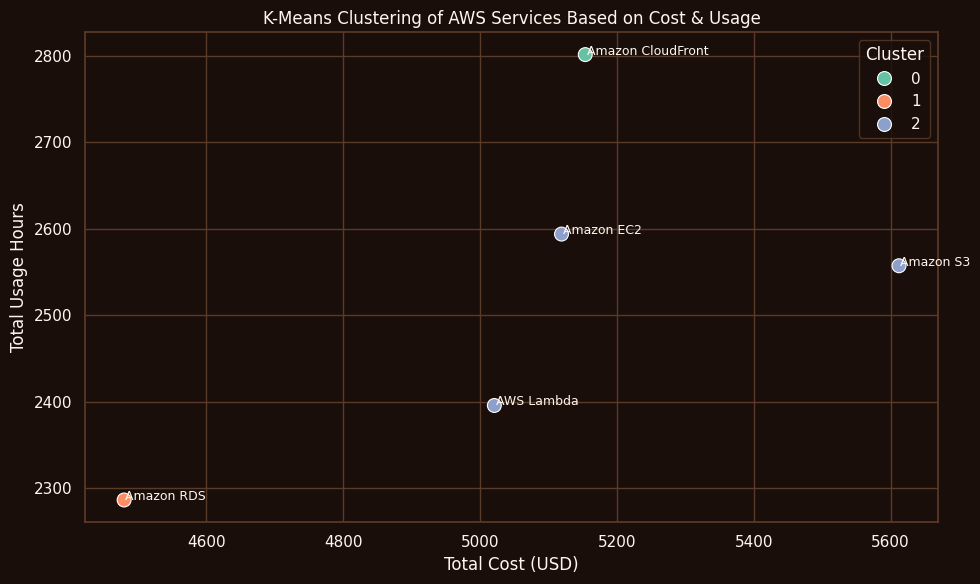

In [6]:
# ===============================================================
# Step 8: K-Means Clustering – Group AWS Services by Behavior
# ---------------------------------------------------------------
# Objective:
# Use unsupervised machine learning to group AWS services based on:
#   - Total Cost (USD)
#   - Total Usage Hours
#
# This helps identify patterns such as:
# - High-cost/high-usage clusters
# - Low-cost, high-efficiency clusters
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
# ===============================================================

# ---------------------------------------------------------------
# 1. Aggregate total Cost and UsageHours per AWS Service
# ---------------------------------------------------------------
# Use groupby + agg to summarize the data per service.
# Resetting index converts 'Service' from index to a column.
# Reference: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
features = df.groupby('Service').agg({
    'Cost': 'sum',             # Total cost for each service
    'UsageHours': 'sum'        # Total usage hours
}).reset_index()

# Optional: Uncomment below to inspect
# print(features.head())

# ---------------------------------------------------------------
# 2. Extract relevant features and standardize them
# ---------------------------------------------------------------
# StandardScaler rescales features to have:
# - Mean = 0
# - Standard Deviation = 1
# This ensures clustering isn’t skewed by large cost values.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
X = features[['Cost', 'UsageHours']]  # Select features
X_scaled = StandardScaler().fit_transform(X)  # Apply scaling

# ---------------------------------------------------------------
# 3. Apply K-Means clustering to scaled features
# ---------------------------------------------------------------
# KMeans will create 3 clusters (n_clusters=3) of services
# using cost and usage behavior as dimensions.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
kmeans = KMeans(n_clusters=3, random_state=42)  # Random seed ensures reproducibility
features['Cluster'] = kmeans.fit_predict(X_scaled)  # Assign cluster label to each row

# ---------------------------------------------------------------
# 4. Visualize the clusters using a scatterplot
# ---------------------------------------------------------------
# Use seaborn’s scatterplot for visualization.
# - X = Cost
# - Y = UsageHours
# - Hue = Cluster group
# - Labels = Service names (manually added for clarity)
# Reference: https://seaborn.pydata.org/generated/seaborn.scatterplot.html
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=features,
    x='Cost',
    y='UsageHours',
    hue='Cluster',
    palette='Set2',
    s=100  # Marker size
)

# Add service names next to each point for clarity
for i in range(len(features)):
    plt.text(
        features['Cost'][i] + 2,        # Slight x-offset
        features['UsageHours'][i],      # y-position
        features['Service'][i],         # Service label
        fontsize=9                      # Font size
    )

# Finalize plot formatting
plt.title("K-Means Clustering of AWS Services Based on Cost & Usage")
plt.xlabel("Total Cost (USD)")
plt.ylabel("Total Usage Hours")
plt.legend(title="Cluster")  # Cluster legend
plt.tight_layout()
plt.show()


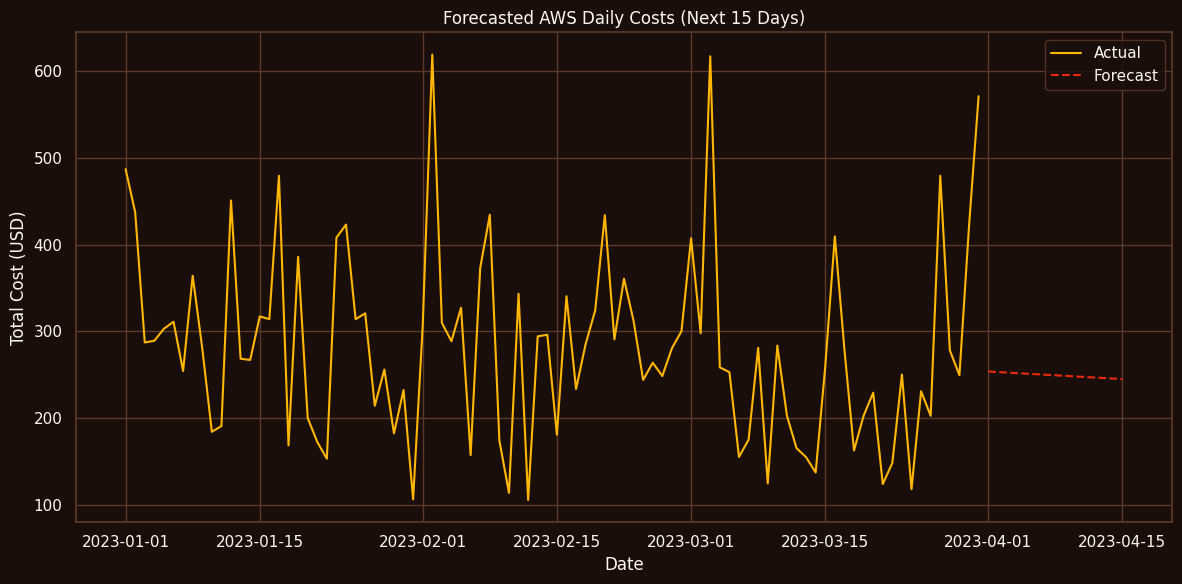

In [7]:
# ===============================================================
# Step 9: Forecasting Future AWS Daily Costs (Linear Regression)
# ---------------------------------------------------------------
# Objective:
# Use historical daily AWS cost data to train a Linear Regression model
# and predict future costs for the next 15 days.
#
# This is a simple time series forecasting technique using supervised learning.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
# ===============================================================

# ---------------------------------------------------------------
# 1. Aggregate total daily cost from the dataset
# ---------------------------------------------------------------
# Group the data by 'Date' and calculate total daily 'Cost'
# This prepares the data for time series modeling
# Reference: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
daily = df.groupby('Date')['Cost'].sum().reset_index()

# ---------------------------------------------------------------
# 2. Convert Date to a numerical format for regression
# ---------------------------------------------------------------
# We'll compute 'DaysSinceStart' — number of days since the first date
# Linear Regression can only work with numeric features
# Reference: https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html
daily['DaysSinceStart'] = (daily['Date'] - daily['Date'].min()).dt.days

# ---------------------------------------------------------------
# 3. Prepare the features (X) and target (y)
# ---------------------------------------------------------------
# Features: Number of days since start
# Target: Daily total cost
X = daily[['DaysSinceStart']]  # Independent variable
y = daily['Cost']              # Dependent variable

# ---------------------------------------------------------------
# 4. Train the Linear Regression model
# ---------------------------------------------------------------
# Fit the regression model to the available historical data
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
model = LinearRegression()
model.fit(X, y)

# ---------------------------------------------------------------
# 5. Forecast next 15 days based on trend
# ---------------------------------------------------------------
# Create future time values (next 15 days from latest day)
# We'll use these to predict future cost
future_days = pd.DataFrame({
    'DaysSinceStart': range(X['DaysSinceStart'].max() + 1, X['DaysSinceStart'].max() + 16)
})

# Predict cost for each of the 15 future days
future_preds = model.predict(future_days)

# Generate corresponding date labels for future predictions
# Reference: https://pandas.pydata.org/docs/reference/api/pandas.date_range.html
future_dates = pd.date_range(start=daily['Date'].max() + pd.Timedelta(days=1), periods=15)

# ---------------------------------------------------------------
# 6. Visualize actual vs forecasted AWS costs
# ---------------------------------------------------------------
# We'll use matplotlib to plot both historical and predicted values
plt.figure(figsize=(12, 6))

# Plot historical costs (blue solid line)
plt.plot(daily['Date'], y, label="Actual", color='#ffb703')

# Plot predicted costs (orange dashed line)
plt.plot(future_dates, future_preds, linestyle='--', label="Forecast", color='#e8290a')

# Final formatting and labeling
plt.title("Forecasted AWS Daily Costs (Next 15 Days)")
plt.xlabel("Date")
plt.ylabel("Total Cost (USD)")
plt.legend()           # Add legend for clarity
plt.grid(True)         # Add grid for readability
plt.tight_layout()     # Avoid overlapping labels
plt.show()             # Display the complete plot


Top 5 Services by Cost Variability (Standard Deviation):
Service
AWS Lambda           14.451713
Amazon EC2           14.431752
Amazon S3            14.184432
Amazon RDS           13.932723
Amazon CloudFront    13.644480
Name: Cost, dtype: float64


/tmp/ipykernel_641/2837287417.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


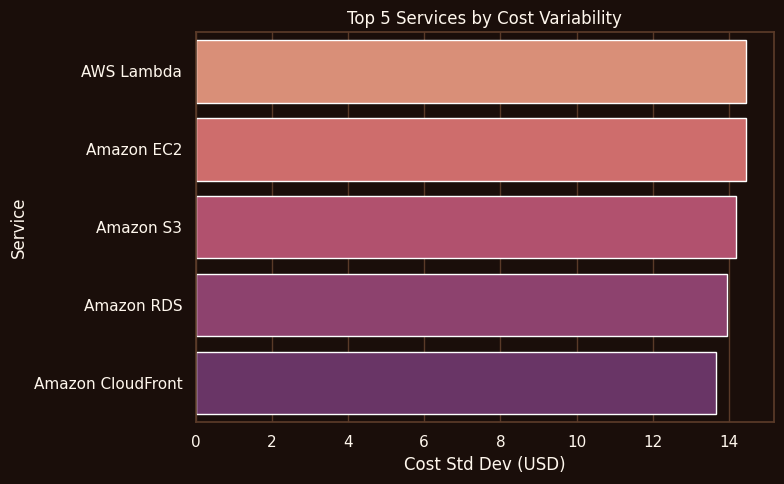

In [8]:
# ===============================================================
# Step 10: Top 5 Services by Cost Variability
# ---------------------------------------------------------------
# Objective:
# Identify the AWS services with the highest variability in cost
# across all entries in the dataset using standard deviation.
#
# Services with high variability may have unpredictable billing
# patterns due to dynamic usage, pricing tiers, or user load.
# ===============================================================

# ---------------------------------------------------------------
# 1. Calculate Standard Deviation of Cost per Service
# ---------------------------------------------------------------
# Group by 'Service' and calculate the standard deviation (std)
# of the 'Cost' column, then sort the result in descending order.
# Reference: https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.std.html
service_variance = df.groupby('Service')['Cost'].std().sort_values(ascending=False).head(5)

# Print the top 5 most variable services by cost
print("Top 5 Services by Cost Variability (Standard Deviation):")
print(service_variance)

# ---------------------------------------------------------------
# 2. Visualize the Result as a Horizontal Bar Chart
# ---------------------------------------------------------------
# Use seaborn's `barplot()` to visually compare the cost variability
# Reference: https://seaborn.pydata.org/generated/seaborn.barplot.html
plt.figure(figsize=(8, 5))  # Set figure dimensions

# Plot horizontal bars showing standard deviation of cost
sns.barplot(
    x=service_variance.values,       # Standard deviation values (cost variability)
    y=service_variance.index,        # Corresponding service names
    palette="flare"                  # Optional color palette for visual enhancement
)

# Customize plot appearance
plt.title("Top 5 Services by Cost Variability")      # Chart title
plt.xlabel("Cost Std Dev (USD)")                     # X-axis label
plt.ylabel("Service")                                # Y-axis label
plt.tight_layout()                                   # Adjust layout to prevent overlap
plt.show()                                           # Display the chart


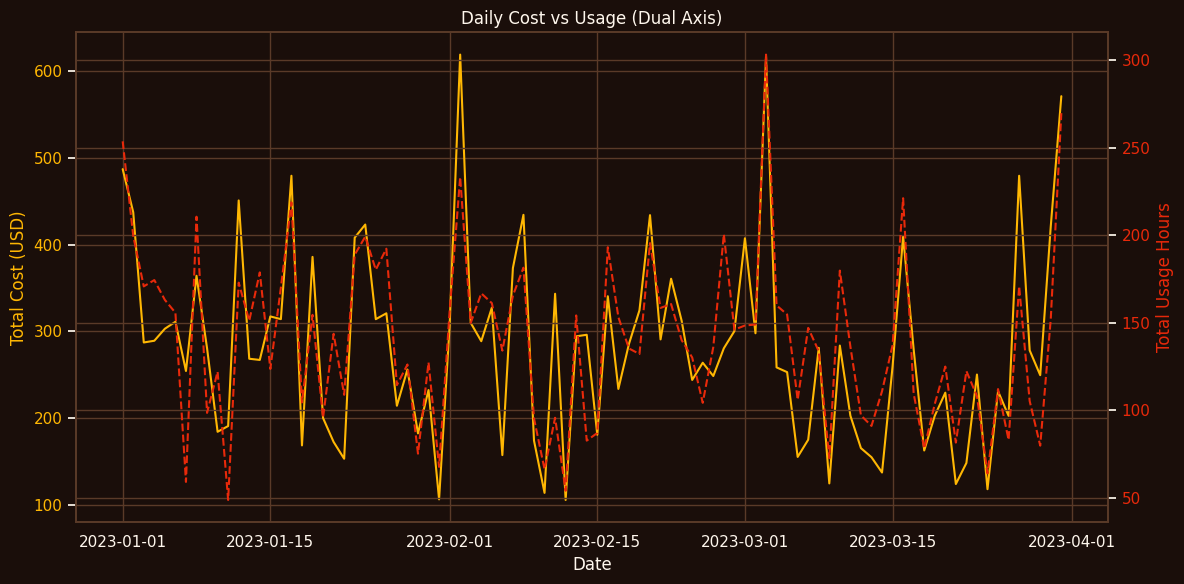

In [9]:
# ===============================================================
# Step 11: Dual-Axis Plot – Daily Cost vs Usage
# ---------------------------------------------------------------
# Objective:
# Compare AWS daily costs and usage hours on the same plot using
# two Y-axes: one for cost and one for usage hours.
#
# Dual-axis plots help you understand if usage patterns drive cost trends.
# ===============================================================

# ---------------------------------------------------------------
# 1. Aggregate total daily cost and usage hours
# ---------------------------------------------------------------
# Group by 'Date' and sum both 'Cost' and 'UsageHours'
# This prepares the data for dual-axis plotting
# Reference: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
daily_sum = df.groupby('Date')[['Cost', 'UsageHours']].sum().reset_index()

# ---------------------------------------------------------------
# 2. Create the figure and first axis (Cost)
# ---------------------------------------------------------------
# Use matplotlib’s object-oriented API to manage two y-axes
# Reference: https://matplotlib.org/stable/gallery/ticks_and_spines/two_scales.html
fig, ax1 = plt.subplots(figsize=(12, 6))  # Define figure and first y-axis

# Set color for cost axis
color = '#ffb703'

# Label the X and Y axes
ax1.set_xlabel('Date')                               # X-axis = Date
ax1.set_ylabel('Total Cost (USD)', color=color)      # Left Y-axis = Cost

# Plot cost line on left axis
ax1.plot(daily_sum['Date'], daily_sum['Cost'], color=color, label='Cost')  # Solid blue line
ax1.tick_params(axis='y', labelcolor=color)  # Match Y-ticks to line color

# ---------------------------------------------------------------
# 3. Create second y-axis (Usage) using twinx()
# ---------------------------------------------------------------
# This overlays a second axis on the right side for usage hours
ax2 = ax1.twinx()  # Mirror axis

# Set color for usage axis
color = '#e8290a'

# Label the second Y-axis
ax2.set_ylabel('Total Usage Hours', color=color)  # Right Y-axis = Usage

# Plot usage line on right axis
ax2.plot(daily_sum['Date'], daily_sum['UsageHours'], color=color, linestyle='--', label='Usage')  # Dashed orange line
ax2.tick_params(axis='y', labelcolor=color)  # Match tick labels to line color

# ---------------------------------------------------------------
# 4. Final plot formatting
# ---------------------------------------------------------------
plt.title("Daily Cost vs Usage (Dual Axis)")  # Chart title
fig.tight_layout()                            # Optimize spacing
plt.show()                                    # Display the plot


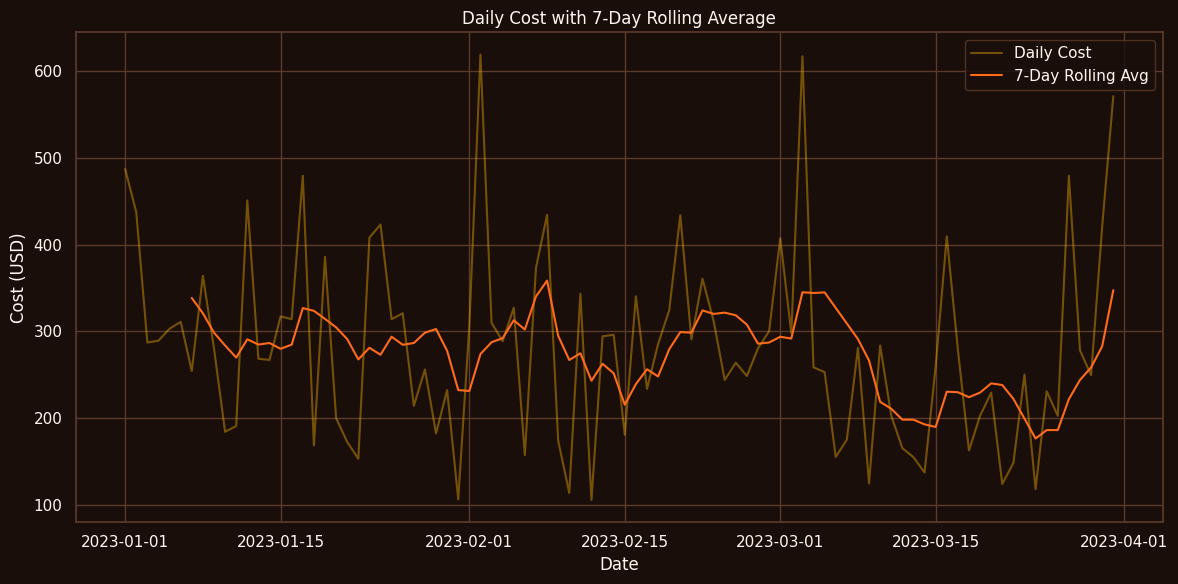

In [10]:
# ===============================================================
# Step 12: Rolling Average of Daily Cost (7-Day Window)
# ---------------------------------------------------------------
# Objective:
# Smooth out short-term fluctuations in AWS daily cost data using
# a 7-day moving (rolling) average. This helps reveal broader trends.
#
# Rolling averages are useful for trend analysis in time-series data.
# Reference: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html
# ===============================================================

# ---------------------------------------------------------------
# 1. Calculate the 7-day rolling average of daily cost
# ---------------------------------------------------------------
# Use the .rolling() function with a window of 7 days and apply .mean()
# This creates a new column called 'RollingAvgCost'
daily_sum['RollingAvgCost'] = daily_sum['Cost'].rolling(window=7).mean()

# ---------------------------------------------------------------
# 2. Plot actual daily cost and rolling average trend
# ---------------------------------------------------------------
# Use matplotlib to overlay both lines on the same chart
# - Original daily cost shown in light color
# - Rolling average shown in red
plt.figure(figsize=(12, 6))  # Set canvas size

# Plot raw daily cost data with slight transparency (alpha)
plt.plot(daily_sum['Date'], daily_sum['Cost'], alpha=0.4, label='Daily Cost')

# Plot the 7-day rolling average in red
plt.plot(daily_sum['Date'], daily_sum['RollingAvgCost'], color='#ff6b1a', label='7-Day Rolling Avg')

# Add labels and title to improve readability
plt.title("Daily Cost with 7-Day Rolling Average")   # Chart title
plt.xlabel("Date")                                   # X-axis label
plt.ylabel("Cost (USD)")                             # Y-axis label
plt.legend()                                         # Add legend for clarity
plt.tight_layout()                                   # Prevent label clipping
plt.show()                                           # Display the chart


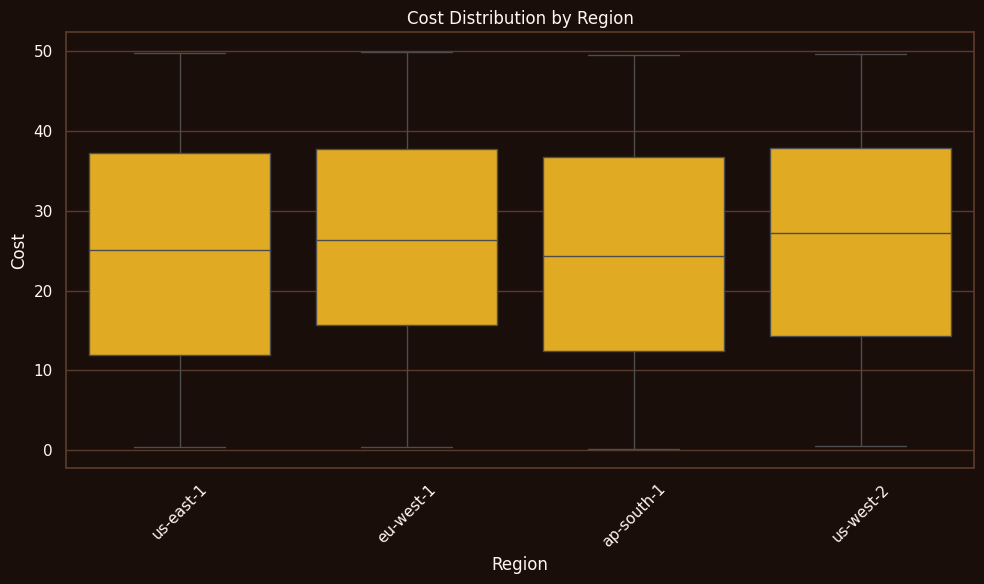

In [11]:
# ===============================================================
# Step 13: Boxplot of Cost by Region
# ---------------------------------------------------------------
# Objective:
# Use a boxplot to understand the distribution of AWS cost across
# different geographic regions.
#
# A boxplot helps visualize:
# - Median cost (central line)
# - Interquartile range (box)
# - Outliers (points outside whiskers)
# Reference: https://seaborn.pydata.org/generated/seaborn.boxplot.html
# ===============================================================

# ---------------------------------------------------------------
# 1. Create the boxplot using seaborn
# ---------------------------------------------------------------
# The X-axis represents AWS regions
# The Y-axis represents cost values for each entry
# Seaborn automatically computes quartiles, whiskers, and outliers
plt.figure(figsize=(10, 6))  # Set the size of the plot

sns.boxplot(
    data=df,               # Source dataset
    x='Region',            # Categorical axis (horizontal) – AWS regions
    y='Cost'               # Numeric axis (vertical) – cost values
)

# ---------------------------------------------------------------
# 2. Enhance plot readability
# ---------------------------------------------------------------
plt.title("Cost Distribution by Region")   # Add title
plt.xticks(rotation=45)                    # Rotate region labels to prevent overlap
plt.tight_layout()                         # Automatically adjust padding
plt.show()                                 # Display the plot


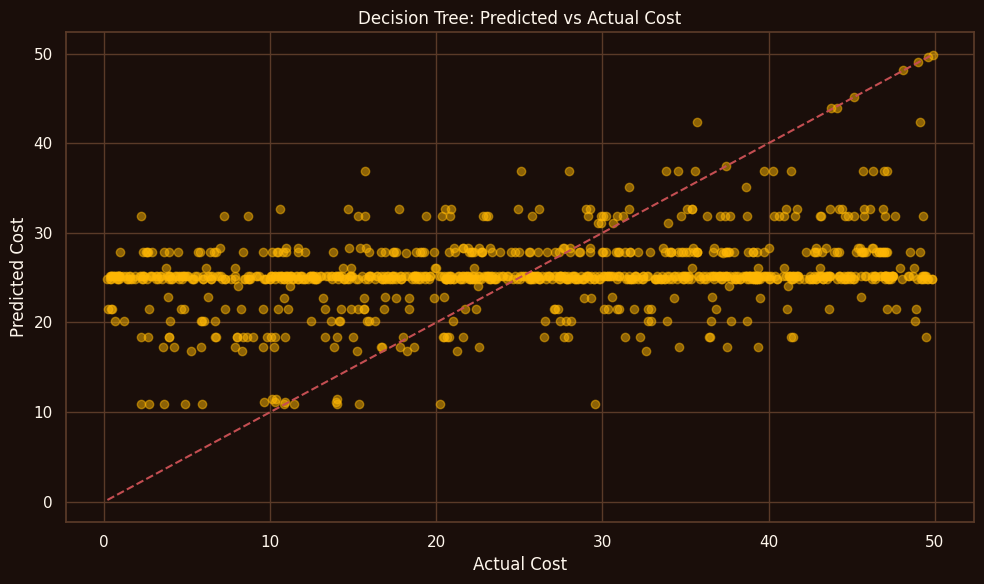

In [12]:
# ===============================================================
# Step 14: Decision Tree Regressor – Predicting Cost from Features
# ---------------------------------------------------------------
# Objective:
# Use a Decision Tree Regression model to predict AWS cost
# based on service type, region, and usage hours.
#
# We'll use scikit-learn's pipeline tools to encode data and model it.
# ===============================================================

# ---------------------------------------------------------------
# 1. Import Required Modules for Preprocessing & Modeling
# ---------------------------------------------------------------
# DecisionTreeRegressor: ML model for regression problems
# OneHotEncoder: Convert categorical columns into numerical dummy variables
# ColumnTransformer: Apply transformations only to specific columns
# Pipeline: Combine preprocessing and modeling steps into one
# Reference: https://scikit-learn.org/stable/modules/compose.html
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ---------------------------------------------------------------
# 2. Define Features and Target Variable
# ---------------------------------------------------------------
# Features: Service type, Region, and UsageHours
# Target: Cost (the value we want to predict)
features = df[['Service', 'Region', 'UsageHours']]
target = df['Cost']

# ---------------------------------------------------------------
# 3. Encode Categorical Features using OneHotEncoding
# ---------------------------------------------------------------
# Convert 'Service' and 'Region' to binary columns
# OneHotEncoder transforms categories into 0/1 numeric indicators
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Service', 'Region'])
], remainder='passthrough')  # Keep 'UsageHours' as is

# ---------------------------------------------------------------
# 4. Build Pipeline: Combine Preprocessing and Model
# ---------------------------------------------------------------
# Pipeline executes:
# Step 1: preprocessor (categorical encoding)
# Step 2: DecisionTreeRegressor (predicts cost)
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
tree_pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=5, random_state=42))
])

# ---------------------------------------------------------------
# 5. Train the Model
# ---------------------------------------------------------------
tree_pipeline.fit(features, target)  # Fit the pipeline on input features

# Predict cost on the same dataset (for comparison)
predicted_cost = tree_pipeline.predict(features)

# ---------------------------------------------------------------
# 6. Plot Predicted vs Actual Cost
# ---------------------------------------------------------------
# Visualizes how well the model fits — ideally a straight 45° line
plt.figure(figsize=(10, 6))

# Plot scatter of actual vs predicted
plt.scatter(target, predicted_cost, alpha=0.5)  # Transparency for readability

# Plot ideal prediction line (perfect prediction reference)
plt.plot([target.min(), target.max()], [target.min(), target.max()], 'r--')

# Add plot labels
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Decision Tree: Predicted vs Actual Cost")
plt.tight_layout()
plt.show()


# **References**

# *General References:*

1. **McKinney, W.** (2024, January 5). Pandas documentation. Pandas Software Foundation.
https://pandas.pydata.org/docs/

2. **W3Schools.** (2024, March 10). Python Pandas Tutorial. W3Schools. https://www.w3schools.com/python/pandas/default.asp

3. **W3Schools.** (2024, March 10). NumPy Tutorial. W3Schools. https://www.w3schools.com/python/numpy/default.asp

4. **W3Schools.** (2024, March 10). Matplotlib Tutorial. W3Schools. https://www.w3schools.com/python/matplotlib_intro.asp

5. **Hunter, J. D.** (2024, January 5). Matplotlib documentation. Matplotlib Developers. https://matplotlib.org/stable/users/index.html

6. **Waskom, M. L.** (2024, January 5). Seaborn documentation. Seaborn Developers. https://seaborn.pydata.org/

7. **Pedregosa, F., Varoquaux, G., Gramfort, A., et al.** (2024, February 7). Scikit-learn user guide. Scikit-learn Developers. https://scikit-learn.org/stable/user_guide.html

8. **Python Software Foundation.** (2024, March 2). The Python Standard Library. Python.org. https://docs.python.org/3/library/index.html



11. **AWS.** (2024, February 1). What is AWS Cloud? Amazon Web Services. https://aws.amazon.com/what-is-aws/


14. **W3Schools.** (2024, March 10). Python datetime module. W3Schools. https://www.w3schools.com/python/python_datetime.asp

15. **W3Schools.** (2024, March 10). Python File Handling. W3Schools. https://www.w3schools.com/python/python_file_handling.asp

16. **W3Schools.** (2024, March 10). Python Functions. W3Schools. https://www.w3schools.com/python/python_functions.asp

17. **W3Schools.** (2024, March 10). Python If...Else Statements. W3Schools. https://www.w3schools.com/python/python_conditions.asp

18. **W3Schools.** (2024, March 10). Python Variables. W3Schools. https://www.w3schools.com/python/python_variables.asp

19. **W3Schools.** (2024, March 10). Python Operators. W3Schools. https://www.w3schools.com/python/python_operators.asp

20. **W3Schools.** (2024, March 10). Python Loops. W3Schools. https://www.w3schools.com/python/python_for_loops.asp

# *Chart & Visualisation References:*

21. **Hunter, J. D.** (2024, January 5). Matplotlib: Python plotting — Line, Bar, Pie, and Dual-Axis Charts. Matplotlib Developers. https://matplotlib.org/stable/users/index.html

22. **Waskom, M. L.** (2024, January 5). Seaborn Statistical Data Visualization Library. Seaborn Developers. https://seaborn.pydata.org/

23. **W3Schools.** (2024, March 10). Python Matplotlib Tutorial – Line Charts and Subplots. W3Schools. https://www.w3schools.com/python/matplotlib_line.asp

24. **W3Schools.** (2024, March 10). Python Seaborn Bar Plot. W3Schools. https://www.w3schools.com/python/matplotlib_bar_charts.asp

25. **W3Schools.** (2024, March 10). Matplotlib Pie Chart in Python. W3Schools. https://www.w3schools.com/python/matplotlib_pie_charts.asp

26. **W3Schools.** (2024, March 10). Python Heatmaps with Seaborn. W3Schools. https://www.w3schools.com/python/matplotlib_heatmaps.asp

27. **W3Schools.** (2024, March 10). Seaborn Boxplot (Distribution Visualization). W3Schools. https://www.w3schools.com/python/matplotlib_boxplots.asp

28. **Stack Overflow Community.** (2024, March 1). Creating dual-axis plots in matplotlib. Stack Overflow. https://stackoverflow.com/

# *Machine Learning References:*

29. **Pedregosa, F., Varoquaux, G., Gramfort, A., et al.** (2024, February 7). Scikit-learn: KMeans Clustering Documentation. Scikit-learn Developers. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

30. **Pedregosa, F., Varoquaux, G., Gramfort, A., et al.** (2024, February 7). Scikit-learn: Linear Regression Model. Scikit-learn Developers. https://scikit-learn.org/stable/modules/linear_model.html#linearregression

31. **Pedregosa, F., Varoquaux, G., Gramfort, A., et al.** (2024, February 7). Scikit-learn: DecisionTreeRegressor Model. Scikit-learn Developers. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

32. **Scikit-learn Developers.** (2024, February 7). Feature Scaling with StandardScaler. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

33. **Scikit-learn Developers.** (2024, February 7). ColumnTransformer for Mixed Preprocessing. https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html

34. **Scikit-learn Developers.** (2024, February 7). Pipeline: Chaining Preprocessing and Estimation. https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
